In [1]:
%load_ext autoreload
%autoreload 2
%cd /opt/tiger/samantha
!pip3 install -q ujson


/opt/tiger/samantha


/home/tiger/.local/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [2]:
from samantha.dataio.data_bucket import data_bucket
from recipes.mi1.data_enriched.reader import IndexReader

2023-12-19 21:35:36,185 - numexpr.utils - INFO - Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
2023-12-19 21:35:36,185 - numexpr.utils - INFO - Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.


In [22]:
# url2index = data_bucket(
#     "data/music/converted/converted_all_LyricsDataModule_SpeechTransform/train/0/url2index.txt"
# )
# print(url2index)
# reader = IndexReader(url2index, cache=True)

url2index = data_bucket(
    "../mcc/mcc60_lossless_asr/vocal_B/2000000/vocal-B-blues.txt"
)
print(url2index)
reader = IndexReader(url2index, cache=True)

hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data/js/../mcc/mcc60_lossless_asr/vocal_B/2000000/vocal-B-blues.txt
Loaded 407 index urls


100%|██████████| 407/407 [02:42<00:00,  2.50it/s]


In [23]:
reader.indexes

,metadata,lyrics,index_url,key
0,"{'meta_song_id': 6944803635033327617, 'meta_so...",{'result': [{'text': 'You got me running. You ...,hdfs://harunava/home/byte_data_seed_us/hdd_va/...,6944803635033327617
1,"{'meta_song_id': 6787732219529005058, 'meta_so...","{'result': [{'text': 'Well, i've been thinking...",hdfs://harunava/home/byte_data_seed_us/hdd_va/...,6787732219529005058
2,"{'meta_song_id': 6767557594912393218, 'meta_so...",{'result': [{'text': 'In a town that's so far ...,hdfs://harunava/home/byte_data_seed_us/hdd_va/...,6767557594912393218
3,"{'meta_song_id': 6815020905819801602, 'meta_so...",{'result': [{'text': 'Temptation calling in a ...,hdfs://harunava/home/byte_data_seed_us/hdd_va/...,6815020905819801602
4,"{'meta_song_id': 6815863198588078082, 'meta_so...","{'result': [{'text': 'Well, i can recall that ...",hdfs://harunava/home/byte_data_seed_us/hdd_va/...,6815863198588078082
...,...,...,...,...
132676,"{'meta_song_id': 6793384158249879553, 'meta_so...",{'result': [{'text': 'All the time in the worl...,hdfs://harunava/home/byte_data_seed_us/hdd_va/...,6793384158249879553
132677,"{'meta_song_id': 7019567181767641089, 'meta_so...","{'result': [{'text': 'Shout out to you. Hey, b...",hdfs://harunava/home/byte_data_seed_us/hdd_va/...,7019567181767641089
132678,"{'meta_song_id': 6853757724019165186, 'meta_so...",{'result': [{'text': 'Longing for my sugar and...,hdfs://harunava/home/byte_data_seed_us/hdd_va/...,6853757724019165186
132679,"{'meta_song_id': 7151517457163749378, 'meta_so...",{'result': [{'text': 'I told you. Stop the agg...,hdfs://harunava/home/byte_data_seed_us/hdd_va/...,7151517457163749378


In [18]:
reader.indexes[reader.indexes.lyrics_normalized_text.duplicated(keep=False)].sort_values(by=["lyrics_normalized_text"]).tail(50)

AttributeError: 'DataFrame' object has no attribute 'lyrics_normalized_text'

<Axes: title={'center': 'Top 50 style texts in mcc60m_vocalB_style_mixed_text_audio'}>

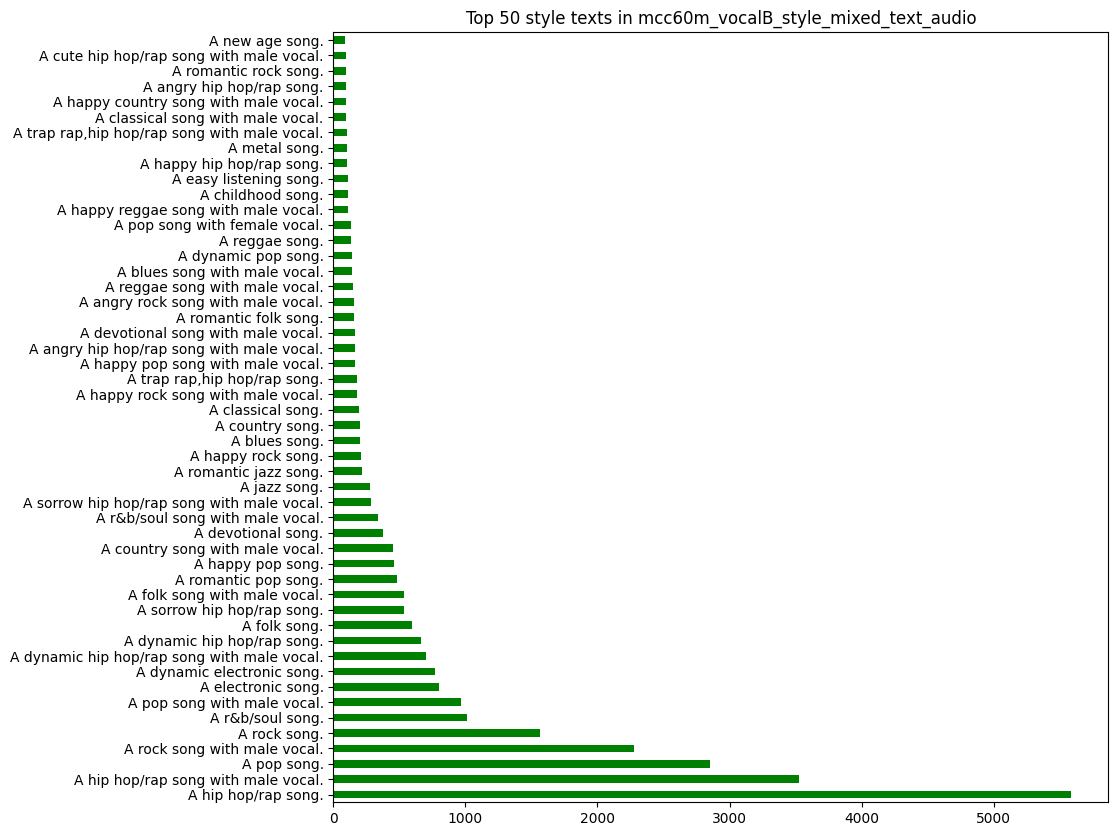

In [10]:
reader.indexes.style_text.value_counts()[:50].plot.barh(figsize=(10,10), title="Top 50 style texts in mcc60m_vocalB_style_mixed_text_audio", color="green")

<Axes: ylabel='style_text'>

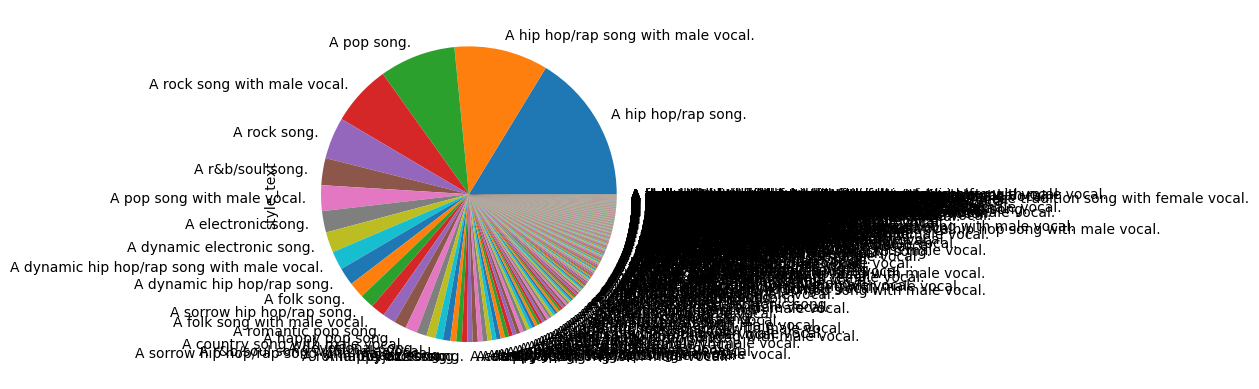

In [11]:
reader.indexes.style_text.value_counts().plot.pie()

In [4]:
from recipes.datasets.preprocessed.mel_spectrogram import CombinedMelDataModule
from samantha.transforms.tokenizers.phoneme import LyricPhonemeTokenizer
from samantha.transforms.audio import plot_spectrogram

batch_size = 20
url2index = "data/music/converted/converted_all_LyricsDataModule_SpeechTransform/train/0/url2index.txt"

lyrics_tokenizer = LyricPhonemeTokenizer()
datamodule = CombinedMelDataModule(
    sample_rate=24000,
    train_url2index=url2index,
    validation_url2index=url2index,
    lyrics_tokenizer=lyrics_tokenizer,
    hop_size=240,
    batch_size=batch_size,
    shuffle_buffer_size=200,
    resampled=False,
    shardshuffle=False,
    min_seconds=1,
    max_seconds=30,
    num_workers=8,
)

ModuleNotFoundError: No module named 'recipes'

In [3]:
dataloader = datamodule.train_dataloader()

NameError: name 'datamodule' is not defined

## MTAT Tags

In [2]:
from recipes.mi1.models.tagging import MI1_MusicTagging, MI1_MusicTaggingInput
from recipes.mi1.models.mi1 import UMMTokenizer
from samantha.utils.hdfs_tools import hdfs_open, hdfs_get_cache

audio_tokenizer = UMMTokenizer()
audio_tokenizer = audio_tokenizer.to("cuda")

m1_ckpt_path = "hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data/js/mi-1_music_tagging/v0_lr1.0e-4_precision32_preload/checkpoints/step=0030000.ckpt"

m1_ckpt_path = hdfs_get_cache(m1_ckpt_path)
m1_model = MI1_MusicTagging.load_from_checkpoint(m1_ckpt_path)
m1_model = m1_model.to("cuda")

m1_model = m1_model.eval()

ModuleNotFoundError: No module named 'recipes'

In [1]:
from tqdm import tqdm

topk = 5
for batch_idx, batch in enumerate(tqdm(dataloader)):
    if batch_idx == 1:
        break
        
    batch.audio = batch.audio.to(audio_tokenizer.device)
    
    result = audio_tokenizer.forward(batch.audio)
    inputs = MI1_MusicTaggingInput(result.hidden_states.clone())

    result = m1_model.predict_tags(inputs, topk=topk)
    
    for idx in range(batch_size):
        # print(batch.style_text[idx], "|| new tags:", result.mcc_tag_names[idx])
        print()
        print("new tags:", result.mcc_tag_names[idx])
        # display(Audio(batch.audio[idx].cpu(), rate=24000))


NameError: name 'dataloader' is not defined

In [49]:
# from tqdm import tqdm
# for batch_idx, batch in enumerate(tqdm(dataloader)):
#     if batch_idx == 100:
#         break

100it [00:34,  2.92it/s]


In [50]:
# import matplotlib.pyplot as plt

# from IPython.display import display, Audio

# for batch_idx, batch in enumerate(tqdm(dataloader)):
#     if batch_idx == 5:
#         break
        
# #     for idx in range(batch_size):
# #         print(batch.lyrics[idx])
# #         print(batch.lyrics_tokens[idx])
# #         print(batch.style_text[idx])
# #         plot_spectrogram(batch.mel[idx].T, plot_log=False, mel=True)  
# #         plt.show()
# #         display(Audio(batch.audio[idx], rate=24000))

